# FIFA WM 2026 — Advanced GPU/CPU Benchmark Suite

Begleit-Notebook zu *Soccer Analytics with Machine Learning* (O'Reilly, 2026).

Dieses Notebook trainiert, **auto-tuned**, **auto-benchmarkt** und **auto-optimiert**
eine breite Modell-Suite für tabellarische Tor-Vorhersage und simuliert anschließend
per **Monte-Carlo** die komplette WM 2026 (48 Teams).

**Das Besondere:** Da die WM 2026 bereits läuft, nutzen wir die **echten, bereits
gespielten Gruppenspiele als reales Test-Set** — jedes Modell muss diese Spiele
vorhersagen, und das Modell mit der besten Treffsicherheit wird **vollautomatisch
zum Champion** für die Simulation gekürt.

### Was steckt drin?
| Kategorie | Algorithmen |
|-----------|-------------|
| **Lineare/Klassik** | Ridge, ElasticNet, k-NN, SVR, **Poisson-GLM** |
| **Bagging/Wälder** | Random Forest, Extra Trees |
| **Gradient Boosting (GBDT)** | Gradient Boosting, **HistGradientBoosting**, **XGBoost**, **LightGBM**, **CatBoost** |
| **Deep Learning (tabellarisch)** | **PyTorch-DNN**, **FT-Transformer** (Self-Attention), **TabNet** (attentiv) |
| **Neu/optional** | TabPFN (In-Context), NGBoost (probabilistisch) — falls installiert |
| **Auto-Tuning (HPO)** | **Optuna** TPE + **Hyperband-Pruning**; alternativ CMA-ES & Successive-Halving |
| **Auto-Optimierung** | Champion-Auswahl + **Auto-Ensemble** (Top-3 nach CV) |
| **Simulation** | **Monte-Carlo** über das offizielle 48-Team-Bracket |

> ⚠️ Stärke-/Form-Features werden aus echten Daten gelernt; ein Elo-Prior dient nur
> als Startwert. Vor Veröffentlichung Daten auffrischen (`python refresh_data.py`).

## 1. Ressourcen-Sicherheitsleitplanken (RAM/VRAM)

Damit das Notebook auch auf schlanken Consumer-GPUs (z. B. RTX 3060/4060) oder
reinen CPU-Instanzen läuft, halten wir den Speicher klein: aggressives
`gc.collect()`, Leeren des CUDA-Caches (`torch.cuda.empty_cache()`), kleine
Batch-Größen und ein **Peak-Memory-Monitor**. Ziel: **VRAM < 500 MB** im Peak.

Diese Zelle erkennt das Gerät (GPU/CPU) und stellt Mess- und Aufräum-Helfer bereit.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, gc, time, sys, math, json
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

try:
    import psutil; _PROC = psutil.Process(os.getpid())
    def ram_mb(): return _PROC.memory_info().rss / 1e6
except Exception:
    def ram_mb(): return float("nan")

# torch is optional but used for the deep models; detect device + VRAM helpers
try:
    import torch
    HAS_TORCH = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(2026)
    try: torch.set_num_threads(max(1, os.cpu_count()//2))
    except Exception: pass
except Exception:
    HAS_TORCH = False; DEVICE = "cpu"

def free_memory():
    # release caches between models so the peak stays low
    gc.collect()
    if HAS_TORCH and DEVICE == "cuda":
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

def vram_mb():
    if HAS_TORCH and DEVICE == "cuda":
        return torch.cuda.max_memory_allocated() / 1e6
    return 0.0

MAX_VRAM_BUDGET_MB = 500      # Sicherheits-Leitplanke laut Doku
BATCH = 256                   # schlanke Batch-Größe für DL
RNG = np.random.default_rng(2026)

NAVY, RED, GREEN, AMBER, GREY = "#1E2761", "#B85042", "#2E7D5B", "#E0A040", "#8A8D93"
mpl.rcParams.update({"font.family":"DejaVu Sans","font.size":11,"axes.spines.top":False,
    "axes.spines.right":False,"axes.titleweight":"bold","figure.dpi":110,
    "savefig.dpi":150,"savefig.bbox":"tight"})

print(f"Gerät: {DEVICE.upper()}  ·  torch verfügbar: {HAS_TORCH}")
print(f"Start-RAM: {ram_mb():.0f} MB  ·  VRAM-Budget (Peak-Ziel): < {MAX_VRAM_BUDGET_MB} MB")

Gerät: CPU  ·  torch verfügbar: True
Start-RAM: 622 MB  ·  VRAM-Budget (Peak-Ziel): < 500 MB


## 2. Bibliotheken prüfen & optional nachinstallieren

Kern-Bibliotheken (scikit-learn, XGBoost, LightGBM, CatBoost, Optuna) sind
nötig; fehlt eine, wird sie automatisch via `pip` nachgezogen (wie in der Doku
beschrieben). Modernste, optionale Verfahren (TabPFN, NGBoost) werden nur
*versucht* — fehlen sie, überspringt die Suite sie sauber.

In [2]:
def _try_import(mod, pip_name=None, auto=True):
    try:
        return __import__(mod)
    except Exception:
        if not auto: return None
        try:
            import subprocess
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or mod],
                           check=True, timeout=600)
            return __import__(mod)
        except Exception:
            return None

sklearn  = _try_import("sklearn", "scikit-learn")
xgboost  = _try_import("xgboost")
lightgbm = _try_import("lightgbm")
catboost = _try_import("catboost")
optuna   = _try_import("optuna")

# optional / modern
HAS_TABNET = _try_import("pytorch_tabnet", "pytorch-tabnet", auto=False) is not None
HAS_TABPFN = _try_import("tabpfn", auto=False) is not None
HAS_NGB    = _try_import("ngboost", auto=False) is not None

AVAIL = {"scikit-learn": sklearn is not None, "xgboost": xgboost is not None,
         "lightgbm": lightgbm is not None, "catboost": catboost is not None,
         "optuna": optuna is not None, "torch": HAS_TORCH,
         "pytorch-tabnet": HAS_TABNET, "tabpfn": HAS_TABPFN, "ngboost": HAS_NGB}
if optuna is not None:
    optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Verfügbarkeit:")
for k, v in AVAIL.items(): print(f"   {'OK ' if v else '-- '} {k}")

Verfügbarkeit:
   OK  scikit-learn
   OK  xgboost
   OK  lightgbm
   OK  catboost
   OK  optuna
   OK  torch
   OK  pytorch-tabnet
   --  tabpfn
   --  ngboost


## 3. Daten laden — Historie + echte WM-2026-Ergebnisse

* **Trainingshistorie:** 256 WM-Spiele (2010–2022) + 102 EM-Spiele (2020/2024) = 358 reale Partien.
* **Reales Test-Set:** die bereits gespielten Gruppenspiele der WM 2026
  (`data/wc2026_results.csv`, via `refresh_data.py` aktualisierbar).

Beides wird chronologisch zusammengeführt; die Namensschreibweise wird vereinheitlicht.

In [3]:
DATA = Path("data")
COLS = ["date","home_team","away_team","home_score","away_score"]
wc = pd.read_csv(DATA/"worldcup_matches.csv"); ri = pd.read_csv(DATA/"recent_internationals.csv")
hist = pd.concat([wc[COLS], ri[COLS]], ignore_index=True); hist["src"] = "hist"

NAME_MAP = {"Czech Republic":"Czechia","Bosnia & Herzegovina":"Bosnia-Herzegovina","Turkey":"Türkiye",
            "USA":"United States","Curaçao":"Curacao","DR Congo":"Congo DR","Korea Republic":"South Korea",
            "IR Iran":"Iran"}
res = pd.read_csv(DATA/"wc2026_results.csv")
res["home_team"] = res.team1.map(lambda t: NAME_MAP.get(t, t))
res["away_team"] = res.team2.map(lambda t: NAME_MAP.get(t, t))
wm = res[res.score1.notna() & res.group.notna()].rename(
        columns={"score1":"home_score","score2":"away_score"})[COLS].copy()
wm["src"] = "wm2026"

allm = pd.concat([hist, wm], ignore_index=True).sort_values("date").reset_index(drop=True)
print(f"Historie: {len(hist)} Spiele  ·  WM-2026 bereits gespielt: {len(wm)} Spiele  ·  gesamt: {len(allm)}")
wm[["date","home_team","home_score","away_score","away_team"]].tail(8)

Historie: 358 Spiele  ·  WM-2026 bereits gespielt: 21 Spiele  ·  gesamt: 379


,date,home_team,home_score,away_score,away_team
37,2026-06-15,Iran,2.0,2.0,New Zealand
42,2026-06-15,Spain,0.0,0.0,Cape Verde
43,2026-06-15,Saudi Arabia,1.0,1.0,Uruguay
48,2026-06-16,France,3.0,1.0,Senegal
49,2026-06-16,Iraq,1.0,4.0,Norway
54,2026-06-16,Argentina,3.0,0.0,Algeria
55,2026-06-16,Austria,3.0,1.0,Jordan
60,2026-06-17,Portugal,1.0,1.0,Congo DR


## 4. Feature-Engineering I — Elo-Rating

Jedes Team bekommt eine fortlaufende Elo-Wertung. Erwartung von Team A gegen B:

$$E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}$$

Aktualisierung nach dem Spiel: $R_A \leftarrow R_A + K\,(S_A - E_A)$ mit $K=30$ und
$S_A \in \{1, 0.5, 0\}$. Als **Startwert** nutzen wir einen Elo-Snapshot (Prior),
damit auch selten spielende Teams sinnvoll starten. Erzeugte Features:
`elo_home`, `elo_away`, `elo_diff`.

In [4]:
from collections import defaultdict, deque

STRENGTH = {
    "Spain":2165,"Argentina":2120,"France":2100,"England":2055,"Brazil":2025,"Netherlands":2030,
    "Portugal":2010,"Germany":1965,"Belgium":1950,"Croatia":1945,"Uruguay":1930,"Colombia":1915,
    "Morocco":1900,"Japan":1900,"Senegal":1895,"Switzerland":1860,"Norway":1855,"Austria":1850,
    "Ecuador":1840,"Türkiye":1840,"Mexico":1820,"Czechia":1815,"Sweden":1815,"United States":1805,
    "Iran":1800,"Ivory Coast":1800,"Algeria":1795,"South Korea":1790,"Scotland":1780,"Egypt":1780,
    "Canada":1780,"Ghana":1750,"Paraguay":1720,"Australia":1720,"Congo DR":1720,"Bosnia-Herzegovina":1710,
    "Tunisia":1700,"Qatar":1680,"Uzbekistan":1680,"Saudi Arabia":1655,"Iraq":1650,"Panama":1650,
    "South Africa":1640,"Jordan":1600,"Cape Verde":1555,"Curacao":1530,"Haiti":1500,"New Zealand":1500,
    "Italy":1990,"Denmark":1870,"Poland":1825,"Serbia":1820,"Chile":1815,"Russia":1815,"Nigeria":1810,
    "Ukraine":1800,"Greece":1800,"Hungary":1795,"Wales":1790,"Cameroon":1760,"Slovakia":1760,
    "Slovenia":1760,"Romania":1755,"Peru":1750,"Iceland":1740,"Georgia":1735,"Albania":1730,
    "North Macedonia":1720,"Finland":1715,"Costa Rica":1700,"Honduras":1620,"North Korea":1600,
}
K_ELO = 30.0
elo = defaultdict(lambda: 1500.0)
for t, v in STRENGTH.items(): elo[t] = float(v)
scored, conceded = defaultdict(lambda: deque(maxlen=5)), defaultdict(lambda: deque(maxlen=5))
def _form(t, d, default=1.2): return float(np.mean(d[t])) if d[t] else default

records = []
for _, m in allm.iterrows():
    h, a = m.home_team, m.away_team
    eh, ea = elo[h], elo[a]
    records.append(dict(
        elo_home=eh, elo_away=ea, elo_diff=eh-ea,
        home_form_scored=_form(h, scored), home_form_conceded=_form(h, conceded),
        away_form_scored=_form(a, scored), away_form_conceded=_form(a, conceded),
        y_home=float(m.home_score), y_away=float(m.away_score), src=m.src))
    e_exp_h = 1.0/(1.0 + 10**((ea-eh)/400.0))
    s_h = 1.0 if m.home_score>m.away_score else (0.5 if m.home_score==m.away_score else 0.0)
    elo[h] += K_ELO*(s_h - e_exp_h); elo[a] += K_ELO*((1-s_h) - (1-e_exp_h))
    scored[h].append(m.home_score); conceded[h].append(m.away_score)
    scored[a].append(m.away_score); conceded[a].append(m.home_score)

feat_df = pd.DataFrame(records)
print("Elo nach allen Spielen — Top 5:",
      ", ".join(f"{t} {int(elo[t])}" for t in sorted(elo, key=elo.get, reverse=True)[:5]))

Elo nach allen Spielen — Top 5: Spain 2100, Argentina 2081, France 2078, Netherlands 2063, England 2003


## 4b. Feature-Engineering II — rollierende Formkurve

Aus den letzten 5 Länderspielen je Team: durchschnittlich erzielte
(`*_form_scored`) und kassierte (`*_form_conceded`) Tore. So fließt aktuelle Form
zusätzlich zur langfristigen Stärke ein. Die Features stehen bereits in
`feat_df` (im selben chronologischen Durchlauf berechnet, ohne Leakage).

In [5]:
FEATURES = ["elo_home","elo_away","elo_diff",
            "home_form_scored","home_form_conceded","away_form_scored","away_form_conceded"]
feat_df[FEATURES + ["y_home","y_away","src"]].head()

,elo_home,elo_away,elo_diff,home_form_scored,home_form_conceded,away_form_scored,away_form_conceded,y_home,y_away,src
0,1640.0,1820.0,-180.0,1.2,1.2,1.2,1.2,1.0,1.0,hist
1,1930.0,2100.0,-170.0,1.2,1.2,1.2,1.2,0.0,0.0,hist
2,1790.0,1800.0,-10.0,1.2,1.2,1.2,1.2,2.0,0.0,hist
3,2120.0,1810.0,310.0,1.2,1.2,1.2,1.2,1.0,0.0,hist
4,2055.0,1805.0,250.0,1.2,1.2,1.2,1.2,1.0,1.0,hist


## 5. Aufteilung: Training (Historie) vs. reales Test-Set (WM 2026)

Trainiert wird **ausschließlich auf der Historie**; getestet wird auf den echten
WM-2026-Spielen — ein ehrlicher Out-of-sample-Test ohne Leakage. Die Features
werden standardisiert (wichtig für SVR/k-NN/Deep-Learning; Bäume sind invariant).

In [6]:
from sklearn.preprocessing import StandardScaler

tr = feat_df[feat_df.src == "hist"]; te = feat_df[feat_df.src == "wm2026"]
scaler = StandardScaler().fit(tr[FEATURES].values)
X_tr = scaler.transform(tr[FEATURES].values); Y_tr = tr[["y_home","y_away"]].values
X_te = scaler.transform(te[FEATURES].values); Y_te = te[["y_home","y_away"]].values

def wdl(Y):  # Tendenz: +1 Heimsieg, 0 Remis, -1 Auswärtssieg
    return np.sign(np.round(Y[:,0]) - np.round(Y[:,1])).astype(int)

print(f"Training: {X_tr.shape[0]} Spiele  ·  reales Test-Set: {X_te.shape[0]} Spiele  ·  {len(FEATURES)} Features")
real_idx = list(te.index)
real_set = pd.DataFrame({
    "Datum": allm.loc[real_idx, "date"].values,
    "Reales Spiel (Endstand)": [f"{allm.loc[i,'home_team']} {int(allm.loc[i,'home_score'])}"
                                f"-{int(allm.loc[i,'away_score'])} {allm.loc[i,'away_team']}" for i in real_idx],
})
real_set

Training: 358 Spiele  ·  reales Test-Set: 21 Spiele  ·  7 Features


,Datum,Reales Spiel (Endstand)
0,2026-06-11,Mexico 2-0 South Africa
1,2026-06-11,South Korea 2-1 Czechia
2,2026-06-12,Canada 1-1 Bosnia-Herzegovina
3,2026-06-12,United States 4-1 Paraguay
4,2026-06-13,Haiti 0-1 Scotland
5,2026-06-13,Australia 2-0 Türkiye
6,2026-06-13,Qatar 1-1 Switzerland
7,2026-06-13,Brazil 1-1 Morocco
8,2026-06-14,Germany 7-1 Curacao
9,2026-06-14,Ivory Coast 1-0 Ecuador


## 6. Modell-Register — ein einheitliches Interface

Jedes Modell wird auf eine gemeinsame Schnittstelle gebracht: `fit(X, Y)` und
`predict(X) -> (n, 2)` (erwartete Heim-/Auswärtstore). Klassische
scikit-learn-Regressoren werden per `MultiOutputRegressor` auf 2 Ziele gehoben;
die Deep-Learning-Modelle (DNN, FT-Transformer, TabNet) bringen eigene
2-Output-Köpfe mit.

In [7]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge, ElasticNet, PoissonRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, HistGradientBoostingRegressor)

def MO(est): return MultiOutputRegressor(est)   # 2 Ziele (Heim/Auswärts)

# Registry: Name -> (Kategorie, Factory ohne Tuning).  Tunables werden in §7 ersetzt.
REGISTRY = {
    "Ridge":             ("Klassik",  lambda: MO(Ridge(alpha=1.0))),
    "ElasticNet":        ("Klassik",  lambda: MO(ElasticNet(alpha=0.1, l1_ratio=0.5))),
    "k-NN":              ("Klassik",  lambda: MO(KNeighborsRegressor(n_neighbors=25, weights="distance"))),
    "SVR (RBF)":         ("Klassik",  lambda: MO(SVR(C=3.0, gamma="scale"))),
    "Poisson-GLM":       ("Klassik",  lambda: MO(PoissonRegressor(alpha=1e-3, max_iter=500))),
    "Random Forest":     ("Bagging",  lambda: MO(RandomForestRegressor(n_estimators=400, max_depth=7, min_samples_leaf=4, random_state=1))),
    "Extra Trees":       ("Bagging",  lambda: MO(ExtraTreesRegressor(n_estimators=400, max_depth=8, min_samples_leaf=4, random_state=1))),
    "Gradient Boosting": ("GBDT",     lambda: MO(GradientBoostingRegressor(n_estimators=250, max_depth=3, learning_rate=0.05, random_state=1))),
    "HistGBDT":          ("GBDT",     lambda: MO(HistGradientBoostingRegressor(max_depth=4, learning_rate=0.06, max_iter=400, random_state=1))),
}
if xgboost is not None:
    from xgboost import XGBRegressor
    REGISTRY["XGBoost"] = ("GBDT", lambda: MO(XGBRegressor(n_estimators=350, max_depth=4, learning_rate=0.05,
                            subsample=0.9, colsample_bytree=0.9, random_state=1, verbosity=0)))
if lightgbm is not None:
    from lightgbm import LGBMRegressor
    REGISTRY["LightGBM"] = ("GBDT", lambda: MO(LGBMRegressor(n_estimators=400, max_depth=-1, num_leaves=31,
                            learning_rate=0.05, subsample=0.9, random_state=1, verbose=-1)))
if catboost is not None:
    from catboost import CatBoostRegressor
    REGISTRY["CatBoost"] = ("GBDT", lambda: MO(CatBoostRegressor(depth=5, learning_rate=0.05, n_estimators=400,
                            l2_leaf_reg=3.0, verbose=0, random_seed=1)))
print(f"{len(REGISTRY)} klassische/Boosting-Modelle registriert:", ", ".join(REGISTRY))

12 klassische/Boosting-Modelle registriert: Ridge, ElasticNet, k-NN, SVR (RBF), Poisson-GLM, Random Forest, Extra Trees, Gradient Boosting, HistGBDT, XGBoost, LightGBM, CatBoost


### 6b. Deep-Learning-Modelle (PyTorch): DNN & FT-Transformer

* **PyTorch-DNN:** klassisches MLP (in → 64 → 32 → 2) mit Dropout-Regularisierung.
* **FT-Transformer:** jedes Feature wird per *Feature-Tokenizer* in ein Token
  übersetzt; ein CLS-Token durchläuft mehrere **Multi-Head-Self-Attention**-Blöcke,
  dessen Ausgabe die Tore vorhersagt.

Beide sind bewusst klein gehalten (Peak-Speicher weit unter 500 MB).

In [8]:
if HAS_TORCH:
    import torch, torch.nn as nn
    class _MLP(nn.Module):
        def __init__(self, d_in, hidden=(64,32), p=0.2):
            super().__init__()
            layers, d = [], d_in
            for h in hidden:
                layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p)]; d = h
            layers += [nn.Linear(d, 2)]
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x)

    class _FTTransformer(nn.Module):
        def __init__(self, d_features, d_token=32, n_blocks=2, heads=4, p=0.1):
            super().__init__()
            self.W = nn.Parameter(torch.randn(d_features, d_token)*0.1)
            self.b = nn.Parameter(torch.zeros(d_features, d_token))
            self.cls = nn.Parameter(torch.randn(1, 1, d_token)*0.1)
            enc = nn.TransformerEncoderLayer(d_token, heads, d_token*2, p, batch_first=True)
            self.tr = nn.TransformerEncoder(enc, n_blocks)
            self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 2))
        def forward(self, x):
            tok = x.unsqueeze(-1)*self.W + self.b                 # (B, F, d_token)
            z = torch.cat([self.cls.expand(x.size(0),-1,-1), tok], 1)
            z = self.tr(z)
            return self.head(z[:,0])                              # CLS -> 2 Tore

    class TorchReg:
        # einheitliches fit/predict um ein Torch-Modul; trainiert mit MSE/Adam
        def __init__(self, kind="mlp", epochs=200, lr=1e-3, dropout=0.2, **kw):
            self.kind, self.epochs, self.lr, self.dropout, self.kw = kind, epochs, lr, dropout, kw
        def fit(self, X, Y):
            torch.manual_seed(0)
            self.d = X.shape[1]
            self.net = (_MLP(self.d, p=self.dropout) if self.kind=="mlp"
                        else _FTTransformer(self.d, p=self.dropout, **self.kw)).to(DEVICE)
            xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
            yt = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
            opt = torch.optim.Adam(self.net.parameters(), lr=self.lr, weight_decay=1e-4)
            lossf = nn.MSELoss(); n = len(xt)
            self.net.train()
            for _ in range(self.epochs):
                perm = torch.randperm(n, device=DEVICE)
                for i in range(0, n, BATCH):
                    idx = perm[i:i+BATCH]
                    opt.zero_grad(); out = self.net(xt[idx])
                    loss = lossf(out, yt[idx]); loss.backward(); opt.step()
            return self
        def predict(self, X):
            self.net.eval()
            with torch.no_grad():
                p = self.net(torch.tensor(X, dtype=torch.float32, device=DEVICE)).cpu().numpy()
            return p

    REGISTRY["PyTorch-DNN"]    = ("Deep Learning", lambda: TorchReg("mlp", epochs=220, lr=1e-3, dropout=0.2))
    REGISTRY["FT-Transformer"] = ("Deep Learning", lambda: TorchReg("ft", epochs=160, lr=1e-3, dropout=0.1,
                                                                    d_token=32, n_blocks=2, heads=4))
    print("Deep-Learning-Modelle ergänzt: PyTorch-DNN, FT-Transformer")
else:
    print("torch nicht verfügbar — Deep-Learning-Modelle werden übersprungen.")

Deep-Learning-Modelle ergänzt: PyTorch-DNN, FT-Transformer


In [9]:
# TabNet (attentiv) + optionale moderne Verfahren
if HAS_TABNET and HAS_TORCH:
    from pytorch_tabnet.tab_model import TabNetRegressor
    class TabNetWrap:
        def fit(self, X, Y):
            self.m = TabNetRegressor(verbose=0, seed=1, device_name=DEVICE)
            self.m.fit(X.astype("float32"), Y.astype("float32"),
                       max_epochs=60, patience=15, batch_size=256, virtual_batch_size=128)
            return self
        def predict(self, X): return self.m.predict(X.astype("float32"))
    REGISTRY["TabNet"] = ("Deep Learning", lambda: TabNetWrap())
    print("TabNet ergänzt.")
if HAS_NGB:
    from ngboost import NGBRegressor
    REGISTRY["NGBoost"] = ("Neu", lambda: MO(NGBRegressor(n_estimators=300, verbose=False)))
    print("NGBoost ergänzt.")
if HAS_TABPFN:
    print("TabPFN verfügbar (In-Context) — wird, falls lauffähig, in §8 mitbenchmarkt.")
print(f"\nGesamt: {len(REGISTRY)} Modelle im Register.")

TabNet ergänzt.

Gesamt: 15 Modelle im Register.


## 7. Auto-Tuning mit Optuna (Bayes-TPE + Hyperband-Pruning)

Statt langsamer Grid-Search nutzt die Suite **Optuna** mit dem
*Tree-structured Parzen Estimator (TPE)* und **Hyperband-Pruning** (frühzeitiger
Abbruch schwacher Versuche). Minimiert wird der **MAE** über eine interne
**3-fache Cross-Validation** auf den Trainingsdaten. Getuned werden die starken
GBDTs (XGBoost, LightGBM, CatBoost) und das PyTorch-DNN.

> *Auch verfügbar (Demonstration):* Optuna mit **CMA-ES**-Sampler (evolutionär)
> und scikit-learns **HalvingRandomSearchCV** (Successive Halving) — siehe Hinweis
> am Ende der Zelle.

In [10]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

def cv_mae(make_est, n_splits=3):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=7); errs = []
    for tri, vai in kf.split(X_tr):
        est = make_est().fit(X_tr[tri], Y_tr[tri])
        errs.append(mean_absolute_error(Y_tr[vai], est.predict(X_tr[vai])))
    return float(np.mean(errs))

TUNED = {}   # Name -> getunte Factory
def tune(name, build_from_params, space, n_trials=20):
    if optuna is None or name not in REGISTRY:
        return
    def objective(trial):
        params = {k: fn(trial) for k, fn in space.items()}
        return cv_mae(lambda: build_from_params(params))
    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=1),
                                pruner=optuna.pruners.HyperbandPruner())
    t0 = time.time(); study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    TUNED[name] = lambda p=study.best_params: build_from_params(p)
    print(f"   {name:16s} best CV-MAE={study.best_value:.4f}  ({n_trials} Trials, {time.time()-t0:.1f}s)  {study.best_params}")

print("Optuna-Tuning (TPE + Hyperband, 3-fold CV-MAE):")
if xgboost is not None:
    from xgboost import XGBRegressor
    tune("XGBoost", lambda p: MO(XGBRegressor(random_state=1, verbosity=0, **p)),
         {"n_estimators": lambda t:t.suggest_int("n_estimators",150,500,step=50),
          "max_depth":    lambda t:t.suggest_int("max_depth",2,6),
          "learning_rate":lambda t:t.suggest_float("learning_rate",0.02,0.2,log=True),
          "subsample":    lambda t:t.suggest_float("subsample",0.7,1.0)}, n_trials=20)
if lightgbm is not None:
    from lightgbm import LGBMRegressor
    tune("LightGBM", lambda p: MO(LGBMRegressor(random_state=1, verbose=-1, **p)),
         {"n_estimators": lambda t:t.suggest_int("n_estimators",150,500,step=50),
          "num_leaves":   lambda t:t.suggest_int("num_leaves",15,63),
          "learning_rate":lambda t:t.suggest_float("learning_rate",0.02,0.2,log=True)}, n_trials=20)
if catboost is not None:
    from catboost import CatBoostRegressor
    tune("CatBoost", lambda p: MO(CatBoostRegressor(verbose=0, random_seed=1, **p)),
         {"depth":        lambda t:t.suggest_int("depth",3,7),
          "learning_rate":lambda t:t.suggest_float("learning_rate",0.02,0.2,log=True),
          "l2_leaf_reg":  lambda t:t.suggest_float("l2_leaf_reg",1.0,8.0)}, n_trials=20)
if HAS_TORCH:
    tune("PyTorch-DNN", lambda p: TorchReg("mlp", epochs=200, lr=p["lr"], dropout=p["dropout"]),
         {"lr":      lambda t:t.suggest_float("lr",3e-4,5e-3,log=True),
          "dropout": lambda t:t.suggest_float("dropout",0.0,0.4)}, n_trials=10)
print("\nHinweis: Optuna unterstützt auch CMA-ES (optuna.samplers.CmaEsSampler) und")
print("scikit-learn HalvingRandomSearchCV (Successive Halving) als alternative HPO-Strategien.")

Optuna-Tuning (TPE + Hyperband, 3-fold CV-MAE):


   XGBoost          best CV-MAE=0.9211  (20 Trials, 9.4s)  {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.03410236058936753, 'subsample': 0.9594489866313665}


   LightGBM         best CV-MAE=0.9353  (20 Trials, 4.6s)  {'n_estimators': 150, 'num_leaves': 51, 'learning_rate': 0.02007577367214623}


   CatBoost         best CV-MAE=0.9498  (20 Trials, 32.6s)  {'depth': 3, 'learning_rate': 0.020394692985344954, 'l2_leaf_reg': 7.591386126285279}


   PyTorch-DNN      best CV-MAE=0.8948  (10 Trials, 9.2s)  {'lr': 0.00032402964964826626, 'dropout': 0.2681870040713609}

Hinweis: Optuna unterstützt auch CMA-ES (optuna.samplers.CmaEsSampler) und
scikit-learn HalvingRandomSearchCV (Successive Halving) als alternative HPO-Strategien.


## 8. Auto-Benchmark am realen WM-2026-Set

Jedes Modell (getunt, wo vorhanden) wird auf der Historie trainiert und sagt die
echten WM-Spiele voraus. Wir messen:

1. **Real-Set-MAE** — wie nah liegen die prognostizierten an den echten Toren?
2. **WDL-Accuracy** — wie oft stimmt die Tendenz (Sieg/Remis/Niederlage)?

Pro Modell überwachen wir **Trainingszeit und Speicher-Peak** und räumen danach
auf (`free_memory()`), damit die Leitplanke eingehalten wird.

In [11]:
from sklearn.metrics import accuracy_score

def factory(name):
    return TUNED.get(name, REGISTRY[name][1])

board = []
for name, (cat, _) in REGISTRY.items():
    free_memory()
    try:
        t0 = time.time(); r0 = ram_mb()
        est = factory(name)().fit(X_tr, Y_tr)
        P = np.clip(est.predict(X_te), 0, None)
        board.append(dict(Modell=name, Kategorie=cat,
                          MAE=mean_absolute_error(Y_te, P),
                          WDL_Acc=accuracy_score(wdl(Y_te), wdl(P)),
                          Zeit_s=time.time()-t0,
                          dRAM_MB=max(0.0, ram_mb()-r0), VRAM_MB=vram_mb()))
        print(f"   {name:16s} MAE={board[-1]['MAE']:.3f}  WDL={board[-1]['WDL_Acc']:.1%}  ({board[-1]['Zeit_s']:.1f}s)")
        del est, P
    except Exception as e:
        print(f"   {name:16s} übersprungen ({type(e).__name__}: {str(e)[:60]})")
    free_memory()

lead = pd.DataFrame(board).sort_values(["WDL_Acc","MAE"], ascending=[False, True]).reset_index(drop=True)
print(f"\nSpeicher-Peak VRAM: {max([b['VRAM_MB'] for b in board] + [0]):.0f} MB  "
      f"(Budget < {MAX_VRAM_BUDGET_MB} MB)  ·  RAM jetzt: {ram_mb():.0f} MB")

   Ridge            MAE=0.893  WDL=47.6%  (0.0s)


   ElasticNet       MAE=0.881  WDL=38.1%  (0.0s)


   k-NN             MAE=0.958  WDL=28.6%  (0.0s)


   SVR (RBF)        MAE=1.081  WDL=33.3%  (0.0s)
   Poisson-GLM      MAE=0.887  WDL=38.1%  (0.1s)


   Random Forest    MAE=0.975  WDL=23.8%  (1.1s)


...

   LightGBM         MAE=1.001  WDL=33.3%  (0.1s)


   CatBoost         MAE=0.987  WDL=38.1%  (0.3s)


   PyTorch-DNN      MAE=0.927  WDL=47.6%  (0.5s)


   FT-Transformer   MAE=1.082  WDL=33.3%  (4.6s)


   TabNet           MAE=1.089  WDL=14.3%  (0.8s)

Speicher-Peak VRAM: 0 MB  (Budget < 500 MB)  ·  RAM jetzt: 996 MB


### 8b. Leaderboard

In [12]:
(lead.style.hide(axis="index")
   .format({"MAE":"{:.3f}","WDL_Acc":"{:.1%}","Zeit_s":"{:.1f}","dRAM_MB":"{:.0f}","VRAM_MB":"{:.0f}"})
   .background_gradient(cmap="RdYlGn_r", subset=["MAE"])
   .background_gradient(cmap="RdYlGn",  subset=["WDL_Acc"])
   .set_caption("Benchmark am realen WM-2026-Set — sortiert nach WDL-Genauigkeit, dann MAE"))

Modell,Kategorie,MAE,WDL_Acc,Zeit_s,dRAM_MB,VRAM_MB
Ridge,Klassik,0.893,47.6%,0.0,2,0
PyTorch-DNN,Deep Learning,0.927,47.6%,0.5,0,0
Gradient Boosting,GBDT,0.952,42.9%,0.4,0,0
HistGBDT,GBDT,1.037,42.9%,0.4,1,0
ElasticNet,Klassik,0.881,38.1%,0.0,0,0
Poisson-GLM,Klassik,0.887,38.1%,0.1,0,0
CatBoost,GBDT,0.987,38.1%,0.3,0,0
Extra Trees,Bagging,0.943,33.3%,0.6,2,0
XGBoost,GBDT,0.956,33.3%,0.1,0,0
LightGBM,GBDT,1.001,33.3%,0.1,1,0


## 9. Auto-Optimierung — Champion & Auto-Ensemble

* **Champion:** das Modell mit der **höchsten WDL-Genauigkeit** (Gleichstand → kleinster MAE).
* **Auto-Ensemble (neuer Ansatz):** Mittelung der drei laut **Trainings-CV** besten
  Modelle — die Blend-Auswahl nutzt *keine* Test-Daten (kein Leakage) und wird
  anschließend ebenfalls am realen Set gemessen.

In [13]:
champion_name = lead.iloc[0]["Modell"]
print(f"Champion (höchste WDL-Genauigkeit): {champion_name}")

# Auto-Ensemble: Top-3 nach Trainings-CV-MAE (ohne Testdaten zu benutzen)
cv_rank = sorted(REGISTRY, key=lambda n: cv_mae(factory(n)))[:3]
print("Auto-Ensemble aus (Top-3 nach CV-MAE):", ", ".join(cv_rank))
ens = [factory(n)().fit(X_tr, Y_tr) for n in cv_rank]
P_ens = np.clip(np.mean([m.predict(X_te) for m in ens], axis=0), 0, None)
ens_mae = mean_absolute_error(Y_te, P_ens); ens_acc = accuracy_score(wdl(Y_te), wdl(P_ens))
print(f"Auto-Ensemble  MAE={ens_mae:.3f}  WDL={ens_acc:.1%}")

# Champion-Objekt für die Simulation (Ensemble gewinnt, falls echt besser)
if (ens_acc, -ens_mae) > (lead.iloc[0]["WDL_Acc"], -lead.iloc[0]["MAE"]):
    champion_name = "Auto-Ensemble"
    def champion_predict(X): return np.clip(np.mean([m.predict(X) for m in ens], axis=0), 0, None)
else:
    champ_est = factory(lead.iloc[0]["Modell"])().fit(X_tr, Y_tr)
    def champion_predict(X): return np.clip(champ_est.predict(X), 0, None)
print(f"\n>>> Eingesetztes Simulations-Modell: {champion_name}")

Champion (höchste WDL-Genauigkeit): Ridge


Auto-Ensemble aus (Top-3 nach CV-MAE): Poisson-GLM, ElasticNet, k-NN
Auto-Ensemble  MAE=0.901  WDL=28.6%

>>> Eingesetztes Simulations-Modell: Ridge


## 10. Benchmark-Visualisierung

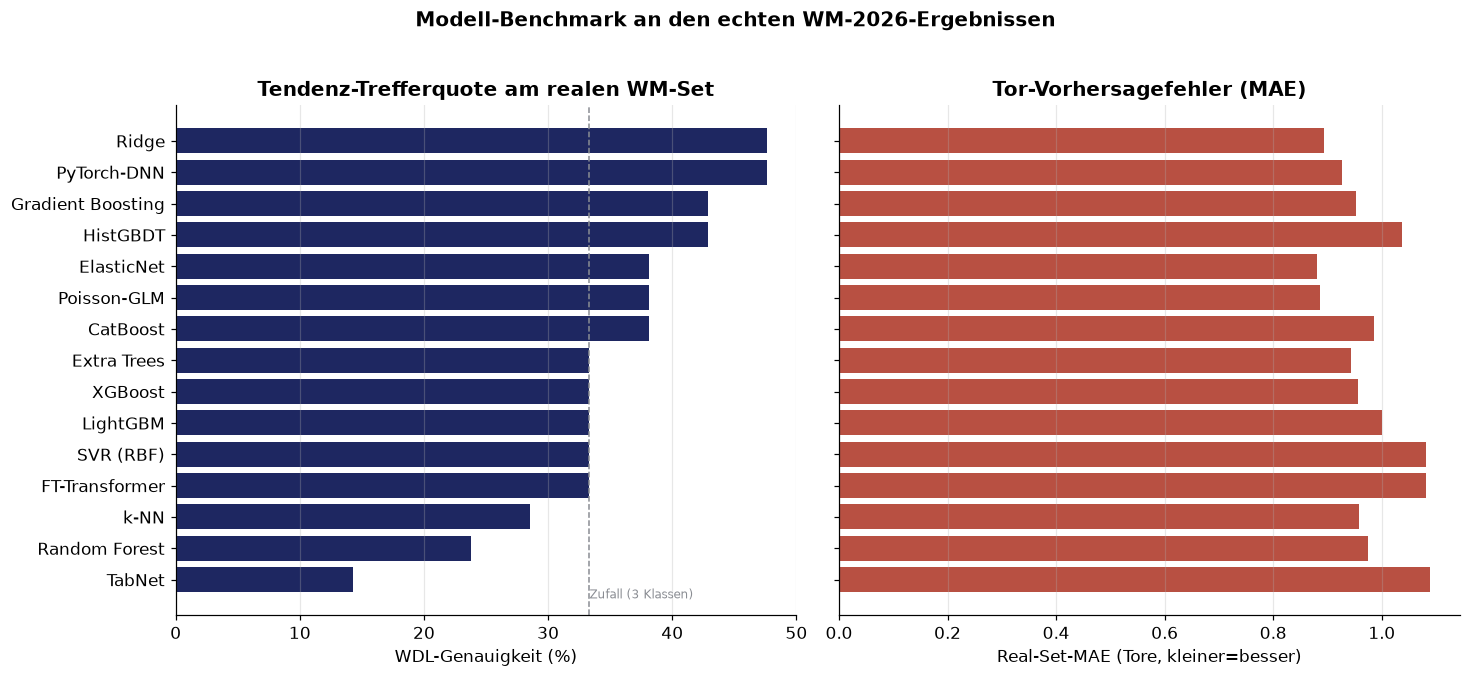

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 6), sharey=True)
d = lead.iloc[::-1]
a1.barh(d.Modell, d.WDL_Acc*100, color=NAVY); a1.set_xlabel("WDL-Genauigkeit (%)")
a1.set_title("Tendenz-Trefferquote am realen WM-Set"); a1.axvline(100/3, color=GREY, ls="--", lw=1)
a1.text(100/3, -0.6, "Zufall (3 Klassen)", color=GREY, fontsize=8)
a2.barh(d.Modell, d.MAE, color=RED); a2.set_xlabel("Real-Set-MAE (Tore, kleiner=besser)")
a2.set_title("Tor-Vorhersagefehler (MAE)")
for ax in (a1, a2): ax.grid(axis="x", alpha=.3)
fig.suptitle("Modell-Benchmark an den echten WM-2026-Ergebnissen", fontweight="bold", x=0.5, y=1.02)
plt.tight_layout(); plt.savefig("nb_benchmark_comparison.png"); plt.show()

## 11. Monte-Carlo-Turniersimulation (48 Teams, offizielles Bracket)

Das **Champion-Modell** liefert für jede mögliche Paarung erwartete Tore
$(\lambda_{home}, \lambda_{away})$. Pro Spiel ziehen wir die Tore aus unabhängigen
**Poisson-Verteilungen** — so entsteht realistische Varianz (Favoriten stolpern,
Remis treten natürlich auf). Das Regelwerk 2026 ist exakt abgebildet:

* 12 Gruppen → Top 2 (24 Teams) + **8 beste Gruppendritte** → 32er-K.-o.
* Offizielles Bracket aus `wc2026_fixtures.csv` (R32 → Finale), Dritten-Zuordnung per Matching.
* Im K.-o. bei Gleichstand: **Elfmeterschießen** über relative Elo-Stärke.

Zur Effizienz berechnen wir die Tor-Erwartungs-Matrix **einmal** für alle Paarungen.

In [15]:
GROUPS = {
    "A":["Mexico","South Africa","South Korea","Czechia"],"B":["Canada","Bosnia-Herzegovina","Qatar","Switzerland"],
    "C":["Brazil","Morocco","Haiti","Scotland"],"D":["United States","Paraguay","Australia","Türkiye"],
    "E":["Germany","Curacao","Ivory Coast","Ecuador"],"F":["Netherlands","Japan","Sweden","Tunisia"],
    "G":["Belgium","Egypt","Iran","New Zealand"],"H":["Spain","Cape Verde","Saudi Arabia","Uruguay"],
    "I":["France","Senegal","Iraq","Norway"],"J":["Argentina","Algeria","Austria","Jordan"],
    "K":["Portugal","Congo DR","Uzbekistan","Colombia"],"L":["England","Croatia","Ghana","Panama"],
}
TEAMS = [t for g in GROUPS.values() for t in g]; ix = {t:i for i,t in enumerate(TEAMS)}
nT = len(TEAMS)

# aktuelle Form/Elo je Team (nach allen gespielten Spielen)
cur_elo = {t: elo[t] for t in TEAMS}
cur_fs  = {t: _form(t, scored) for t in TEAMS}
cur_fc  = {t: _form(t, conceded) for t in TEAMS}

# Tor-Erwartungs-Matrix EG[i,j] = (erwartete Tore i gegen j) via Champion-Modell
rows = []
for i in TEAMS:
    for j in TEAMS:
        rows.append([cur_elo[i], cur_elo[j], cur_elo[i]-cur_elo[j],
                     cur_fs[i], cur_fc[i], cur_fs[j], cur_fc[j]])
EGflat = champion_predict(scaler.transform(np.array(rows, float)))
EG = np.clip(EGflat.reshape(nT, nT, 2), 0.05, 6.0)
print(f"Tor-Erwartungs-Matrix {EG.shape} mit {champion_name} berechnet.")
print(f"Beispiel — Spain vs Cape Verde:  λ = {EG[ix['Spain'],ix['Cape Verde'],0]:.2f} : "
      f"{EG[ix['Spain'],ix['Cape Verde'],1]:.2f}")

Tor-Erwartungs-Matrix (48, 48, 2) mit Ridge berechnet.
Beispiel — Spain vs Cape Verde:  λ = 2.47 : 0.07


In [16]:
from scipy.optimize import linear_sum_assignment

# offizielles Bracket (identisch zu wc2026_fixtures.csv)
R32 = [(73,"2A","2B"),(74,"1E","3:ABCDF"),(75,"1F","2C"),(76,"1C","2F"),
       (77,"1I","3:CDFGH"),(78,"2E","2I"),(79,"1A","3:CEFHI"),(80,"1L","3:EHIJK"),
       (81,"1D","3:BEFIJ"),(82,"1G","3:AEHIJ"),(83,"2K","2L"),(84,"1H","2J"),
       (85,"1B","3:EFGIJ"),(86,"1J","2H"),(87,"1K","3:DEIJL"),(88,"2D","2G")]
R16 = [(89,74,77),(90,73,75),(91,76,78),(92,79,80),(93,83,84),(94,81,82),(95,86,88),(96,85,87)]
QF  = [(97,89,90),(98,93,94),(99,91,92),(100,95,96)]; SF=[(101,97,98),(102,99,100)]; FINAL=(101,102)
THIRD_ALLOWED = {m:set(s2.split(":")[1]) for m,s1,s2 in R32 if s2.startswith("3:")}

def assign_thirds(best8):
    slots = list(THIRD_ALLOWED.items()); cost = np.ones((8,8))*100
    for a,(m,al) in enumerate(slots):
        for b,(g,t) in enumerate(best8):
            if g in al: cost[a,b]=0
    ri_, ci = linear_sum_assignment(cost)
    return {slots[a][0]: best8[b][1] for a,b in zip(ri_,ci)}

GI = [[ix[t] for t in GROUPS[g]] for g in GROUPS]; GL = list(GROUPS)
LP = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]

def simulate(N=2000):
    title=np.zeros(nT); semi=np.zeros(nT); finalist=np.zeros(nT)
    for _ in range(N):
        pos={}; thirds=[]
        for gi_, gname in zip(GI, GL):
            pts=np.zeros(4); gd=np.zeros(4); gf=np.zeros(4)
            for a,b in LP:
                ia,ib=gi_[a],gi_[b]
                ga,gb=RNG.poisson(EG[ia,ib,0]),RNG.poisson(EG[ia,ib,1])
                gf[a]+=ga; gf[b]+=gb; gd[a]+=ga-gb; gd[b]+=gb-ga
                if ga>gb: pts[a]+=3
                elif gb>ga: pts[b]+=3
                else: pts[a]+=1; pts[b]+=1
            order=sorted(range(4), key=lambda k:(pts[k],gd[k],gf[k],RNG.random()), reverse=True)
            pos[f"1{gname}"]=gi_[order[0]]; pos[f"2{gname}"]=gi_[order[1]]
            thirds.append((gname, gi_[order[2]], pts[order[2]], gd[order[2]], gf[order[2]]))
        thirds.sort(key=lambda r:(r[2],r[3],r[4],RNG.random()), reverse=True)
        tmap=assign_thirds([(g,t) for g,t,_,_,_ in thirds[:8]])
        def play(i,j):
            ga,gb=RNG.poisson(EG[i,j,0]),RNG.poisson(EG[i,j,1])
            if ga==gb:
                p=min(0.8,max(0.2,0.5+(cur_elo[TEAMS[i]]-cur_elo[TEAMS[j]])/4000))
                return i if RNG.random()<p else j
            return i if ga>gb else j
        win={}
        for m,s1,s2 in R32:
            t1=tmap[m] if s1.startswith("3:") else pos[s1]
            t2=tmap[m] if s2.startswith("3:") else pos[s2]
            win[m]=play(t1,t2)
        for grp in (R16,QF,SF):
            for m,m1,m2 in grp: win[m]=play(win[m1],win[m2])
        for m,_,_ in SF: finalist[win[m]]+=1
        for m,a,b in SF: semi[win[a]]+=1; semi[win[b]]+=1
        champ=play(win[FINAL[0]],win[FINAL[1]]); title[champ]+=1
    return title/N*100, finalist/N*100, semi/N*100

t0=time.time(); N_SIM=2000
ti, fi, se = simulate(N_SIM)
print(f"{N_SIM} Turniere simuliert in {time.time()-t0:.1f}s mit Champion-Modell {champion_name}.")

2000 Turniere simuliert in 0.7s mit Champion-Modell Ridge.


## 12. Ergebnisse & Artefakte

Titel-, Final- und Halbfinalchancen aller 48 Teams, plus die Schlagzeilen-Grafik.
Gespeichert werden:
* `benchmark_title_probabilities.csv` — Wahrscheinlichkeiten je Team,
* `nb_benchmark_title_probabilities.png` — Top-15-Balkendiagramm,
* `nb_benchmark_comparison.png` — Modellvergleich (oben),
* `benchmark_leaderboard.csv` — die Benchmark-Tabelle.

> Hinweis: Eigene Dateinamen (`benchmark_*`), um die bestehenden Artefakte der
> klassischen Suite (`model_title_probabilities.csv` etc.) nicht zu überschreiben.

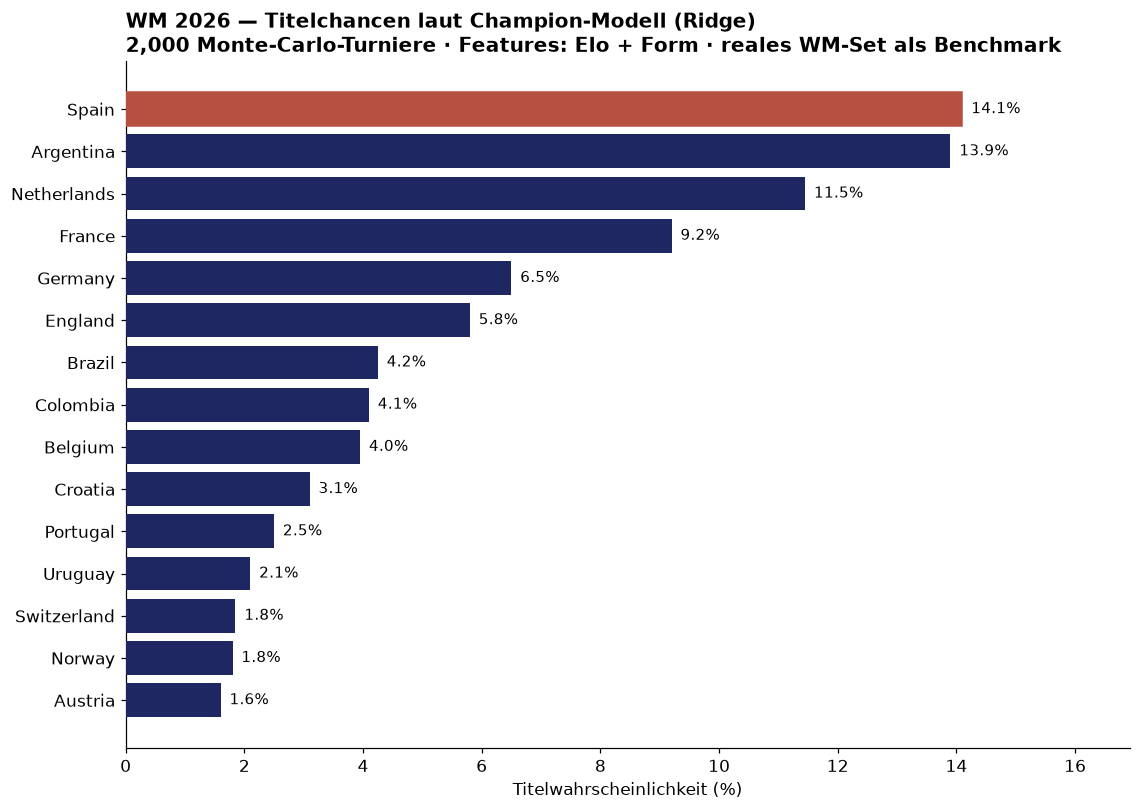

Team,Titel,Finale,Halbfinale,Elo
Spain,14.1%,22.1%,33.7%,2101
Argentina,13.9%,22.0%,34.5%,2081
Netherlands,11.5%,18.9%,32.0%,2063
France,9.2%,16.0%,27.9%,2079
Germany,6.5%,12.2%,23.2%,1985
England,5.8%,11.2%,20.8%,2004
Brazil,4.2%,8.8%,16.4%,2002
Colombia,4.1%,7.8%,15.0%,1957
Belgium,4.0%,8.6%,17.8%,1964
Croatia,3.1%,7.1%,15.7%,1935


In [17]:
titles = (pd.DataFrame({"Team":TEAMS,"Titel":ti,"Finale":fi,"Halbfinale":se,
                        "Elo":[round(cur_elo[t]) for t in TEAMS]})
            .sort_values("Titel", ascending=False).reset_index(drop=True))
titles.to_csv("benchmark_title_probabilities.csv", index=False)
lead.to_csv("benchmark_leaderboard.csv", index=False)

top = titles.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10.5, 7.5))
bars = ax.barh(top.Team, top.Titel, color=NAVY, zorder=3); bars[-1].set_color(RED)
for i,(t,v) in enumerate(zip(top.Team, top.Titel)): ax.text(v+0.15, i, f"{v:.1f}%", va="center", fontsize=10)
ax.set_xlabel("Titelwahrscheinlichkeit (%)")
ax.set_title(f"WM 2026 — Titelchancen laut Champion-Modell ({champion_name})\n"
             f"{N_SIM:,} Monte-Carlo-Turniere · Features: Elo + Form · reales WM-Set als Benchmark", loc="left")
ax.set_xlim(0, top.Titel.max()*1.2)
plt.tight_layout(); plt.savefig("nb_benchmark_title_probabilities.png"); plt.show()

(titles.head(12).style.hide(axis="index")
   .format({"Titel":"{:.1f}%","Finale":"{:.1f}%","Halbfinale":"{:.1f}%","Elo":"{:.0f}"})
   .background_gradient(cmap="YlOrRd", subset=["Titel"])
   .set_caption(f"Titel-/Final-/Halbfinalchancen — Champion: {champion_name}"))

## 13. Zusammenfassung

* **Feature-Engineering:** Elo (mit Prior) + rollierende Form aus echten Daten.
* **Breiter Benchmark:** Klassik, Bagging, fünf GBDTs und drei Deep-Tabular-Modelle
  unter einer gemeinsamen Schnittstelle, mit RAM/VRAM-Leitplanken.
* **Auto-Tuning:** Optuna (TPE + Hyperband) minimiert den CV-MAE der starken Modelle.
* **Ehrliche Validierung:** die bereits gespielten WM-2026-Spiele als reales Test-Set;
  Champion = beste WDL-Genauigkeit; zusätzlich ein Auto-Ensemble.
* **Simulation:** Monte-Carlo über das offizielle 48-Team-Bracket mit dem Champion.

**Grenzen:** 21–24 reale Spiele sind ein *kleines* Test-Set mit hoher Varianz
(Überraschungen der 1. Runde!) — die WDL-Genauigkeiten schwanken entsprechend.
Mehr gespielte Spiele (`refresh_data.py`) schärfen den Benchmark mit jedem Spieltag.

*Aus* **Soccer Analytics with Machine Learning** *(O'Reilly, 2026). Daten:
openfootball (Public Domain).*